In [3]:
import pandas as pd
import numpy as np

# Sri Lanka Tourism Dataset (2000-2023)
np.random.seed(42)

data = {
    'year': list(range(2000, 2024)),
    'total_arrivals': [400000, 436000, 393000, 500000, 566000, 549000, 559000,
                       494000, 438000, 448000, 654000, 856000, 1006000, 1275000,
                       1527000, 1798000, 2051000, 2116000, 2334000, 1913000,
                       507000, 194000, 719000, 1500000],
    'revenue_usd_million': [247, 272, 259, 320, 380, 385, 411, 384, 318, 350,
                             576, 830, 1039, 1360, 1629, 1921, 2238, 2270, 2564,
                             2021, 682, 438, 1335, 2100],
    'avg_stay_days': [9.2, 9.5, 9.1, 9.8, 10.2, 10.0, 10.3, 9.9, 9.5, 9.7,
                      10.5, 11.2, 11.8, 12.1, 12.5, 12.8, 13.0, 12.9, 13.2,
                      12.8, 10.5, 8.9, 11.5, 12.8],
    'top_source_country': ['India', 'India', 'UK', 'India', 'India', 'India',
                            'India', 'India', 'India', 'India', 'India', 'India',
                            'India', 'India', 'India', 'India', 'India', 'India',
                            'India', 'India', 'India', 'India', 'India', 'India'],
    'india_arrivals': [56000, 62000, 58000, 71000, 82000, 80000, 85000, 76000,
                       68000, 72000, 113000, 161000, 195000, 263000, 329000,
                       394000, 473000, 455000, 503000, 424000, 105000, 39000,
                       158000, 350000],
    'uk_arrivals': [52000, 55000, 51000, 62000, 68000, 66000, 69000, 63000,
                    57000, 61000, 82000, 98000, 114000, 138000, 159000, 178000,
                    195000, 198000, 212000, 176000, 48000, 18000, 65000, 140000],
    'germany_arrivals': [28000, 31000, 29000, 35000, 40000, 38000, 41000, 37000,
                          33000, 36000, 51000, 65000, 78000, 95000, 112000, 128000,
                          143000, 148000, 159000, 131000, 35000, 13000, 48000, 100000],
    'china_arrivals': [5000, 6000, 5500, 7000, 9000, 8500, 10000, 9000, 8000,
                       9500, 15000, 22000, 35000, 55000, 80000, 115000, 158000,
                       178000, 195000, 145000, 28000, 10000, 38000, 95000],
    'season': ['low', 'high', 'low', 'high', 'high', 'high', 'high', 'low',
               'low', 'low', 'high', 'high', 'high', 'high', 'high', 'high',
               'high', 'high', 'high', 'high', 'low', 'low', 'high', 'high']
}

df = pd.DataFrame(data)
print(df.head(10))
print("\nShape:", df.shape)
print("\nColumns:", df.columns.tolist())

   year  total_arrivals  revenue_usd_million  avg_stay_days  \
0  2000          400000                  247            9.2   
1  2001          436000                  272            9.5   
2  2002          393000                  259            9.1   
3  2003          500000                  320            9.8   
4  2004          566000                  380           10.2   
5  2005          549000                  385           10.0   
6  2006          559000                  411           10.3   
7  2007          494000                  384            9.9   
8  2008          438000                  318            9.5   
9  2009          448000                  350            9.7   

  top_source_country  india_arrivals  uk_arrivals  germany_arrivals  \
0              India           56000        52000             28000   
1              India           62000        55000             31000   
2                 UK           58000        51000             29000   
3              India  

In [4]:
print("Missing values:")
print(df.isnull().sum())
print("\nBasic Statistics:")
print(df.describe())

# Add revenue per tourist column
df['revenue_per_tourist'] = (df['revenue_usd_million'] * 1000000) / df['total_arrivals']
df['revenue_per_tourist'] = df['revenue_per_tourist'].round(2)

print("\nRevenue per tourist added!")
print(df[['year', 'total_arrivals', 'revenue_usd_million', 'revenue_per_tourist']].head(10))

Missing values:
year                   0
total_arrivals         0
revenue_usd_million    0
avg_stay_days          0
top_source_country     0
india_arrivals         0
uk_arrivals            0
germany_arrivals       0
china_arrivals         0
season                 0
dtype: int64

Basic Statistics:
              year  total_arrivals  revenue_usd_million  avg_stay_days  \
count    24.000000    2.400000e+01            24.000000      24.000000   
mean   2011.500000    9.680417e+05          1013.708333      10.987500   
std       7.071068    6.610377e+05           792.287359       1.463858   
min    2000.000000    1.940000e+05           247.000000       8.900000   
25%    2005.750000    4.825000e+05           372.500000       9.775000   
50%    2011.500000    6.100000e+05           629.000000      10.500000   
75%    2017.250000    1.506750e+06          1702.000000      12.575000   
max    2023.000000    2.334000e+06          2564.000000      13.200000   

       india_arrivals    uk_arrival

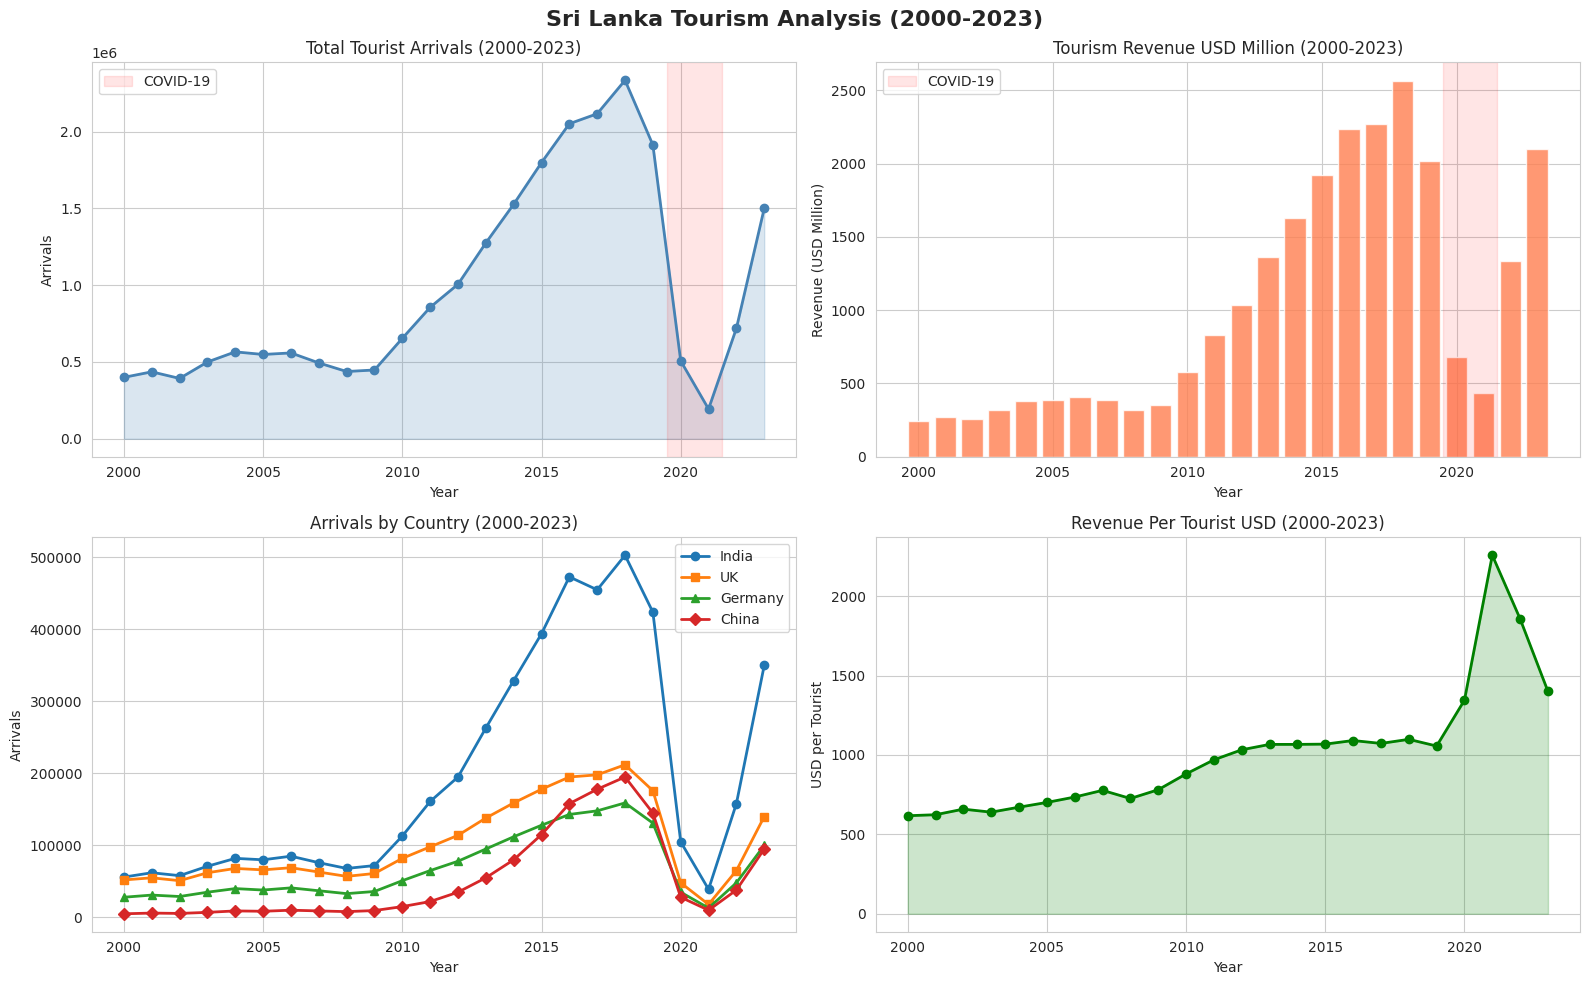

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Sri Lanka Tourism Analysis (2000-2023)", fontsize=16, fontweight='bold')

# Chart 1 — Tourist Arrivals Over Years
axes[0,0].plot(df['year'], df['total_arrivals'], marker='o', color='steelblue', linewidth=2)
axes[0,0].fill_between(df['year'], df['total_arrivals'], alpha=0.2, color='steelblue')
axes[0,0].set_title("Total Tourist Arrivals (2000-2023)")
axes[0,0].set_xlabel("Year")
axes[0,0].set_ylabel("Arrivals")
axes[0,0].axvspan(2019.5, 2021.5, color='red', alpha=0.1, label='COVID-19')
axes[0,0].legend()

# Chart 2 — Revenue Over Years
axes[0,1].bar(df['year'], df['revenue_usd_million'], color='coral', alpha=0.8)
axes[0,1].set_title("Tourism Revenue USD Million (2000-2023)")
axes[0,1].set_xlabel("Year")
axes[0,1].set_ylabel("Revenue (USD Million)")
axes[0,1].axvspan(2019.5, 2021.5, color='red', alpha=0.1, label='COVID-19')
axes[0,1].legend()

# Chart 3 — Tourist Arrivals by Country
axes[1,0].plot(df['year'], df['india_arrivals'], marker='o', label='India', linewidth=2)
axes[1,0].plot(df['year'], df['uk_arrivals'], marker='s', label='UK', linewidth=2)
axes[1,0].plot(df['year'], df['germany_arrivals'], marker='^', label='Germany', linewidth=2)
axes[1,0].plot(df['year'], df['china_arrivals'], marker='D', label='China', linewidth=2)
axes[1,0].set_title("Arrivals by Country (2000-2023)")
axes[1,0].set_xlabel("Year")
axes[1,0].set_ylabel("Arrivals")
axes[1,0].legend()

# Chart 4 — Revenue Per Tourist
axes[1,1].plot(df['year'], df['revenue_per_tourist'], marker='o', color='green', linewidth=2)
axes[1,1].fill_between(df['year'], df['revenue_per_tourist'], alpha=0.2, color='green')
axes[1,1].set_title("Revenue Per Tourist USD (2000-2023)")
axes[1,1].set_xlabel("Year")
axes[1,1].set_ylabel("USD per Tourist")

plt.tight_layout()
plt.show()

In [6]:
import sqlite3

# Create a database in memory
conn = sqlite3.connect(':memory:')

# Save dataframe as SQL table
df.to_sql('tourism', conn, index=False, if_exists='replace')

print("✅ Database created!")
print("Table 'tourism' loaded with", len(df), "rows")

✅ Database created!
Table 'tourism' loaded with 24 rows


In [7]:
# Query 1 — Top 5 best years by tourist arrivals
print("=" * 50)
print("TOP 5 BEST YEARS BY TOURIST ARRIVALS")
print("=" * 50)
q1 = pd.read_sql_query("""
    SELECT year, total_arrivals, revenue_usd_million
    FROM tourism
    ORDER BY total_arrivals DESC
    LIMIT 5
""", conn)
print(q1.to_string(index=False))

# Query 2 — Average revenue by season
print("\n" + "=" * 50)
print("AVERAGE REVENUE BY SEASON")
print("=" * 50)
q2 = pd.read_sql_query("""
    SELECT season,
           ROUND(AVG(total_arrivals), 0) as avg_arrivals,
           ROUND(AVG(revenue_usd_million), 2) as avg_revenue_million
    FROM tourism
    GROUP BY season
    ORDER BY avg_revenue_million DESC
""", conn)
print(q2.to_string(index=False))

# Query 3 — Years where revenue per tourist was above average
print("\n" + "=" * 50)
print("YEARS WITH ABOVE AVERAGE REVENUE PER TOURIST")
print("=" * 50)
q3 = pd.read_sql_query("""
    SELECT year, total_arrivals, revenue_per_tourist
    FROM tourism
    WHERE revenue_per_tourist > (SELECT AVG(revenue_per_tourist) FROM tourism)
    ORDER BY revenue_per_tourist DESC
""", conn)
print(q3.to_string(index=False))

# Query 4 — India vs UK vs Germany vs China total arrivals
print("\n" + "=" * 50)
print("TOTAL ARRIVALS BY COUNTRY (2000-2023)")
print("=" * 50)
q4 = pd.read_sql_query("""
    SELECT
        SUM(india_arrivals) as India,
        SUM(uk_arrivals) as UK,
        SUM(germany_arrivals) as Germany,
        SUM(china_arrivals) as China
    FROM tourism
""", conn)
print(q4.to_string(index=False))

TOP 5 BEST YEARS BY TOURIST ARRIVALS
 year  total_arrivals  revenue_usd_million
 2018         2334000                 2564
 2017         2116000                 2270
 2016         2051000                 2238
 2019         1913000                 2021
 2015         1798000                 1921

AVERAGE REVENUE BY SEASON
season  avg_arrivals  avg_revenue_million
  high     1197588.0              1273.59
   low      410571.0               382.57

YEARS WITH ABOVE AVERAGE REVENUE PER TOURIST
 year  total_arrivals  revenue_per_tourist
 2021          194000              2257.73
 2022          719000              1856.75
 2023         1500000              1400.00
 2020          507000              1345.17
 2018         2334000              1098.54
 2016         2051000              1091.18
 2017         2116000              1072.78
 2015         1798000              1068.41
 2014         1527000              1066.80
 2013         1275000              1066.67
 2019         1913000            

In [8]:
# Save main dataset
df.to_csv('tourism_cleaned.csv', index=False)

# Save SQL query results
q1.to_csv('top5_years.csv', index=False)
q2.to_csv('season_analysis.csv', index=False)
q3.to_csv('revenue_per_tourist.csv', index=False)

print("✅ Files saved!")
print("\nFiles ready for Power BI:")
print("  1. tourism_cleaned.csv")
print("  2. top5_years.csv")
print("  3. season_analysis.csv")
print("  4. revenue_per_tourist.csv")

✅ Files saved!

Files ready for Power BI:
  1. tourism_cleaned.csv
  2. top5_years.csv
  3. season_analysis.csv
  4. revenue_per_tourist.csv


In [9]:
print(df.shape)
print(df.head(2))

(24, 11)
   year  total_arrivals  revenue_usd_million  avg_stay_days  \
0  2000          400000                  247            9.2   
1  2001          436000                  272            9.5   

  top_source_country  india_arrivals  uk_arrivals  germany_arrivals  \
0              India           56000        52000             28000   
1              India           62000        55000             31000   

   china_arrivals season  revenue_per_tourist  
0            5000    low               617.50  
1            6000   high               623.85  
